Fase 1. Generacion de Datos sinteticos en base a sesgos del problema

In [1]:
# Dependencias#
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
def load_data_local(ubicacion):
    try:
        df = pd.read_csv(ubicacion)
        return df
    except Exception as e:
        print(f"Error al cargar la B.D.: {e}")
        return None

In [6]:
# El diccionario va a estar configurado de la siguiente manera #
# Nombre Hospital || Columna Sesgo || Min,Max#
config_sesgos = {
    'Hospital Sírio-Libanês': {
        'mortality_rate_30day':{
            'min': 0.9, 'max': 1.1
            }},
    'Hospital Israelita Albert Einstein': {
        'mortality_rate_30day':{
            'min': 1.1, 'max': 1.3
            }},
    'Hospital CIMA': {
        'mortality_rate_30day':{
            'min': 1.2, 'max': 1.5
            }},
    'Hospital Universitario de Caracas': {
        'readmission_rate_30day':{
            'min': 26, 'max': 27
            }},
    'Hospital Escuela Dr. Roberto Calderón': {
        'hf_mortality_rate':{'min': 5.3, 'max': 5.9},
        'hf_readmission_rate':{'min': 21,'max':27}
        },
    'Hospital Escuela': {
        'hf_mortality_rate':{'min': 4.9, 'max': 5.5},
        'hf_readmission_rate':{'min': 20,'max':22}
        },
    'Hospital Roosevelt': {
        'hf_mortality_rate':{'min': 4.2, 'max': 4.8},
        'hf_readmission_rate':{'min': 18,'max':20}
        }
}

In [7]:
def aumentar_ruleta_con_validacion(df, n_deseado, reglas_hospitales):
    datos_validados = []
    intentos = 0

    # Probabilidades iguales para la ruleta
    probabilidades = np.ones(len(df)) / len(df)
    # Mapa de identidad: { 'Hospital xD': 101 }
    mapa_identidad = df.set_index('hospital_name')['hospital_id'].to_dict()

    print("Iniciando selección por ruleta con validación...")

    while len(datos_validados) < n_deseado:
        # 1. Girar la ruleta
        indice_elegido = np.random.choice(df.index, p=probabilidades)
        candidato = df.loc[indice_elegido].copy()
        
        nombreHospital = str(candidato['hospital_name']).strip()
        
        # Reiniciar bandera
        cumple_todas_las_reglas = True 
        
        if nombreHospital in reglas_hospitales:
            reglas_del_hospital = reglas_hospitales[nombreHospital]
            
            for columna, limites in reglas_del_hospital.items():
                if columna in candidato:
                    valor = candidato[columna]
                    if not (limites['min'] <= valor <= limites['max']):
                        cumple_todas_las_reglas = False
                        break 
            
            if cumple_todas_las_reglas:
                # Sustitución de ID por mapa
                if nombreHospital in mapa_identidad:
                    candidato['hospital_id'] = mapa_identidad[nombreHospital]
                datos_validados.append(candidato)
        else:
            # Si el hospital no tiene reglas, se acepta directo
            if nombreHospital in mapa_identidad:
                candidato['hospital_id'] = mapa_identidad[nombreHospital]
            datos_validados.append(candidato)
            
        intentos += 1
        if intentos > n_deseado * 1000:
            print(f"Límite alcanzado. Logrados: {len(datos_validados)}")
            break

    df_nuevos = pd.DataFrame(datos_validados).reset_index(drop=True)
    df_total = pd.concat([df, df_nuevos], ignore_index=True)
    
    return df_total, df_nuevos

In [8]:
def graficar_diferencia_datos(df_original, df_nuevos, columna_objetivo):
    plt.figure(figsize=(10, 6))
    
    # 1. Línea de densidad para los datos originales
    sns.kdeplot(df_original[columna_objetivo], 
                label='Datos Originales', 
                color='blue', 
                linewidth=3, 
                fill=True, 
                alpha=0.2)
    
    # 2. Línea de densidad para los datos generados por ruleta
    sns.kdeplot(df_nuevos[columna_objetivo], 
                label='Nuevos Datos (Ruleta)', 
                color='red', 
                linestyle='--', 
                linewidth=2)

    plt.title(f'Diferencia de Distribución en la variable: {columna_objetivo}')
    plt.xlabel('Valor de la Variable')
    plt.ylabel('Densidad de Datos')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

Iniciando selección por ruleta con validación...


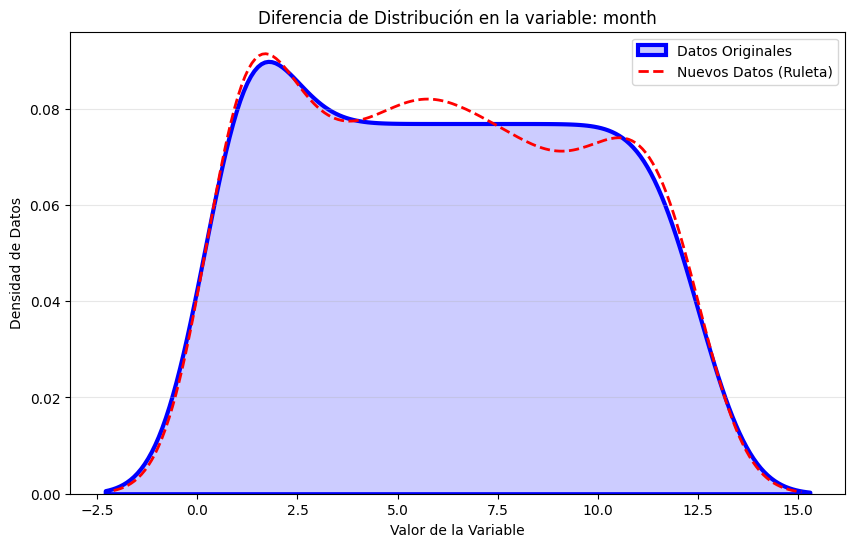

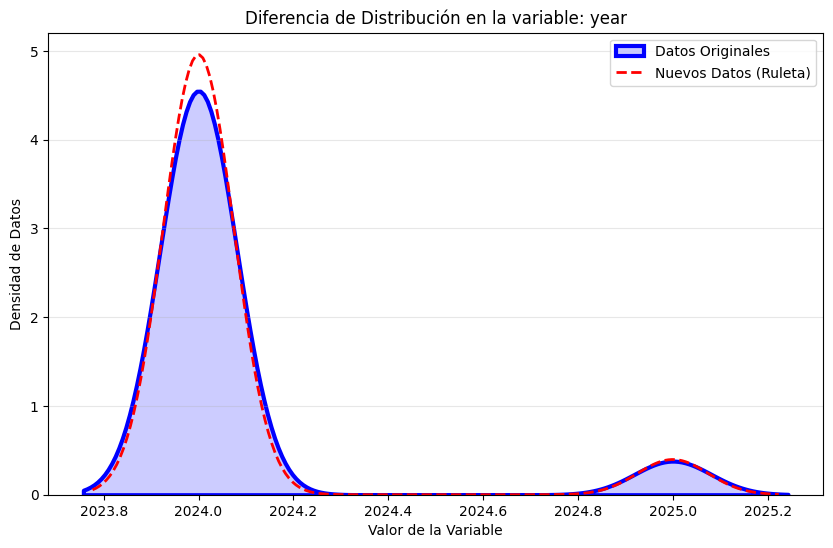

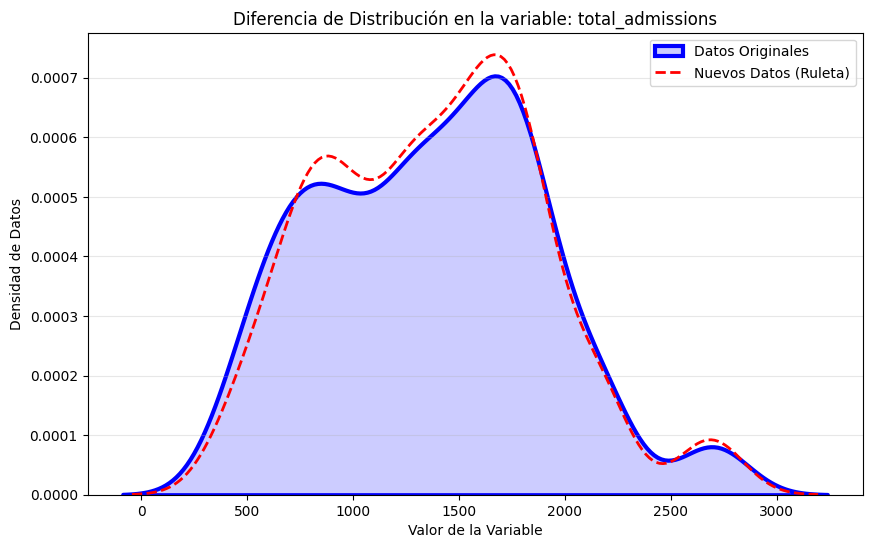

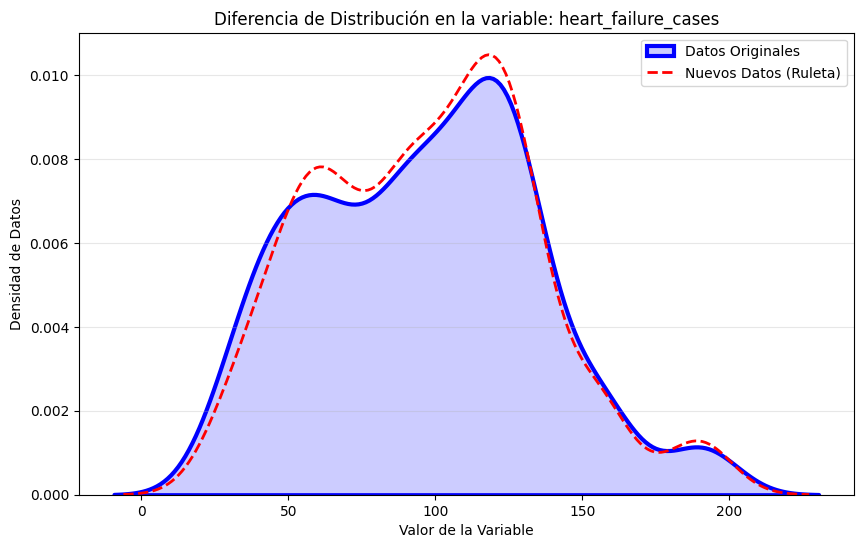

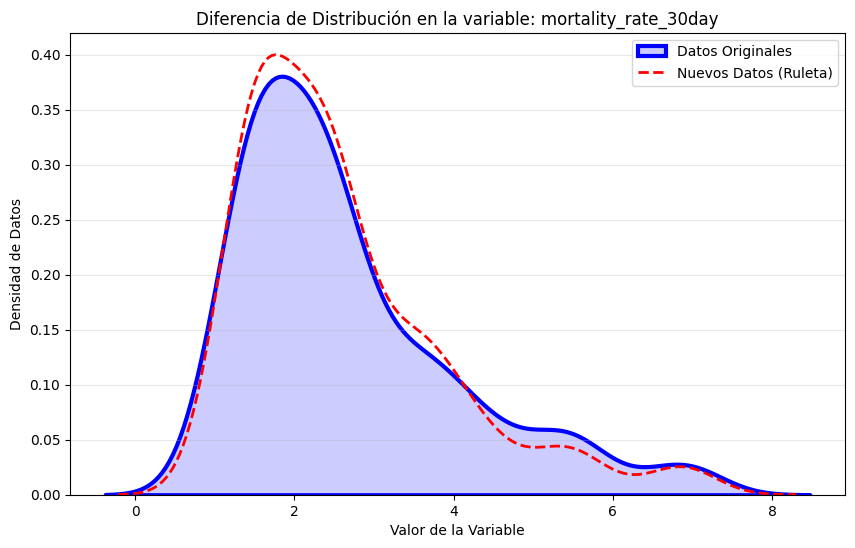

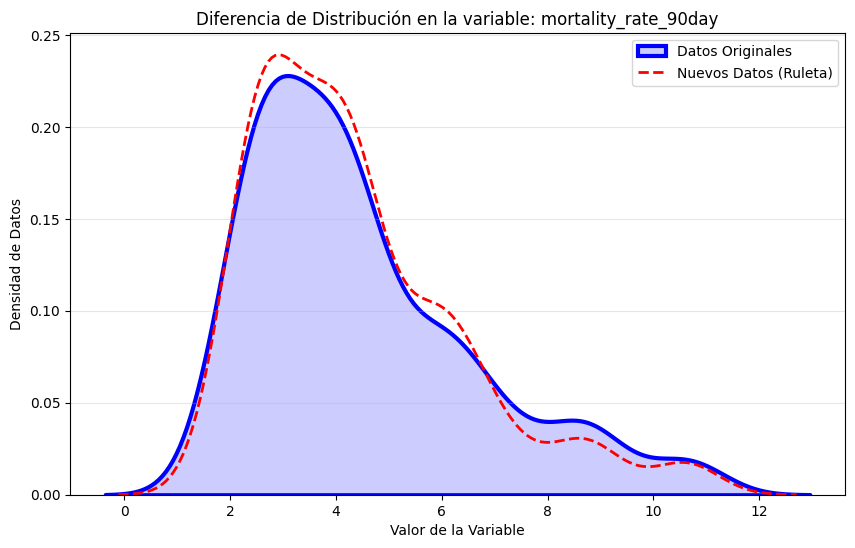

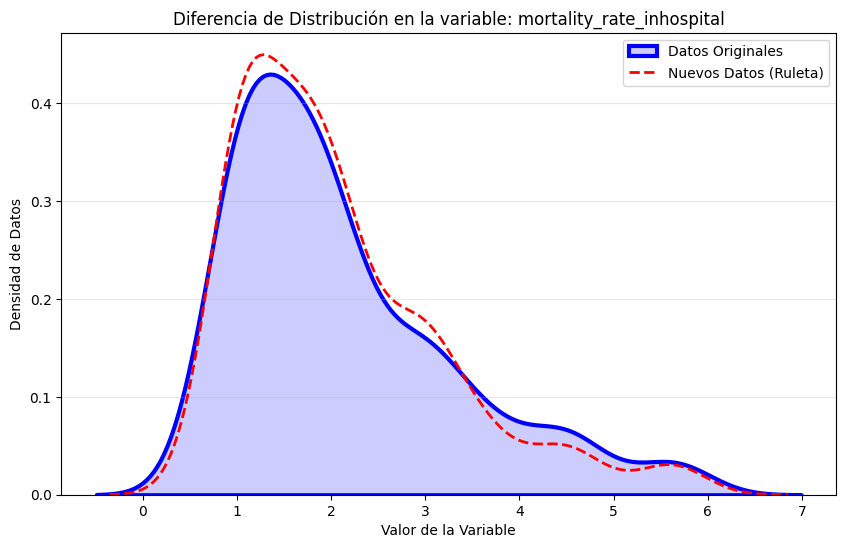

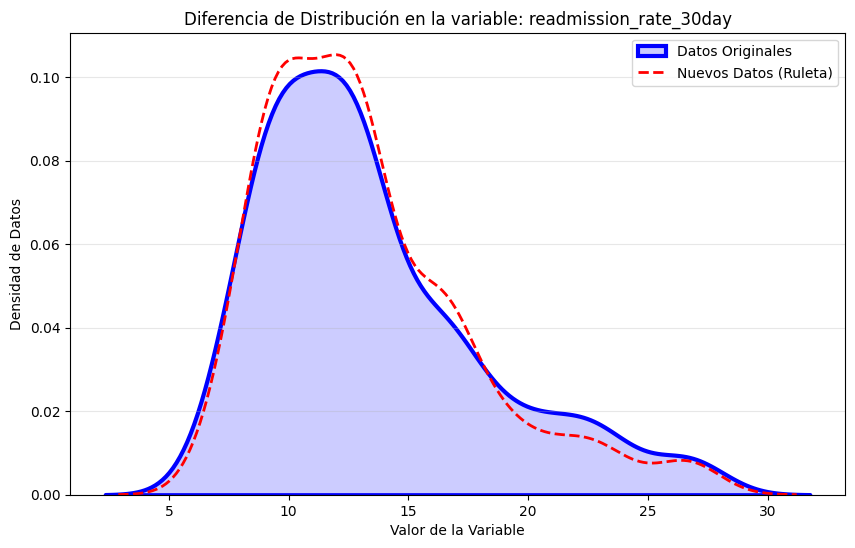

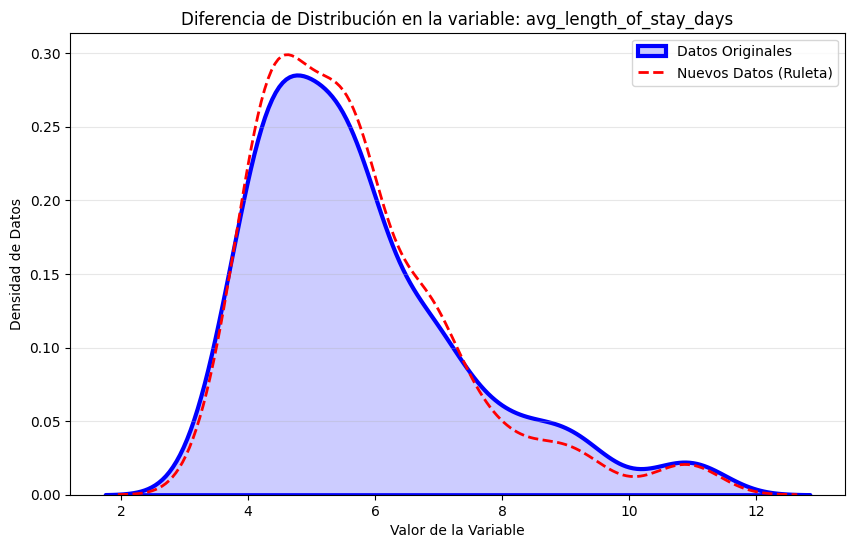

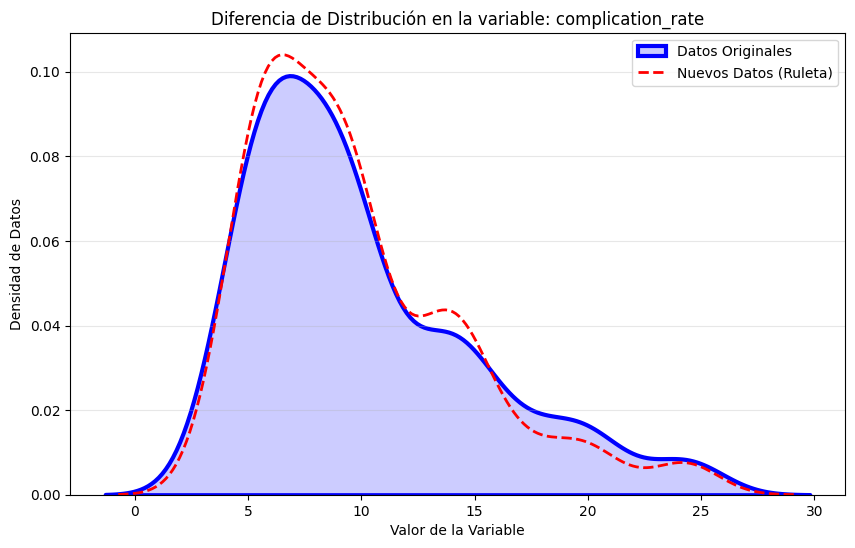

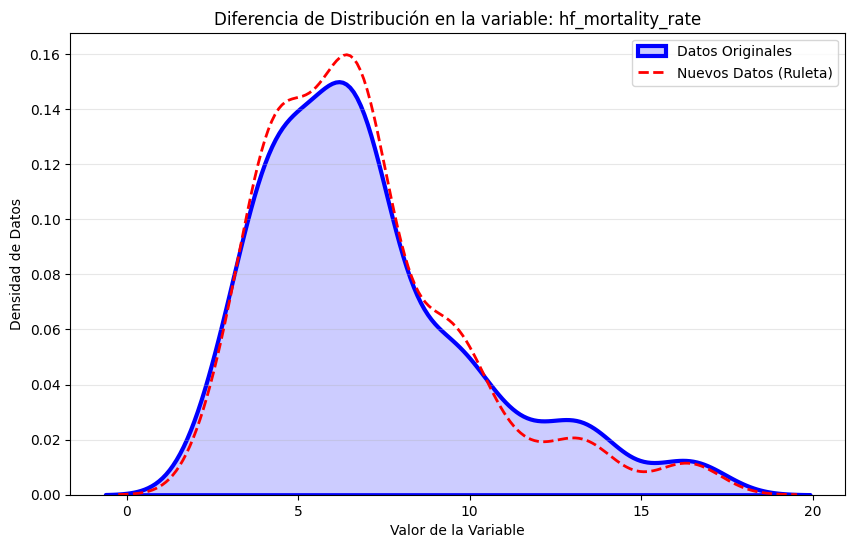

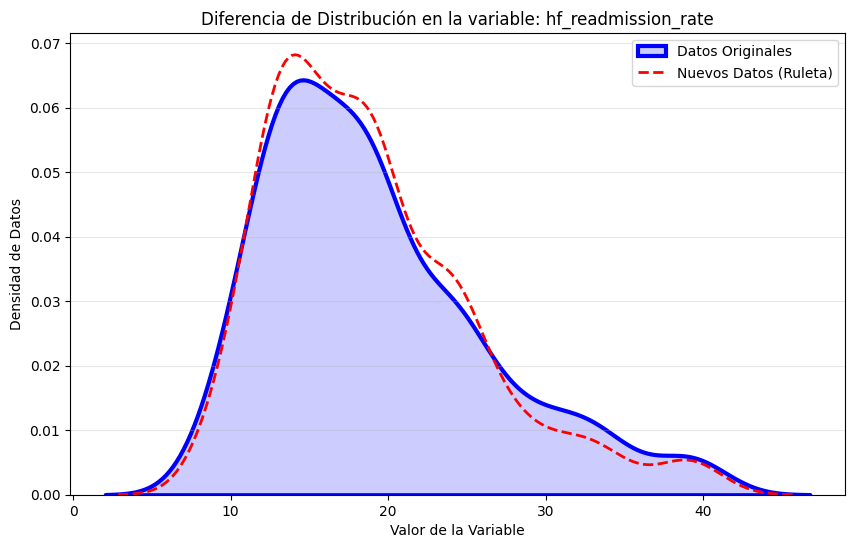

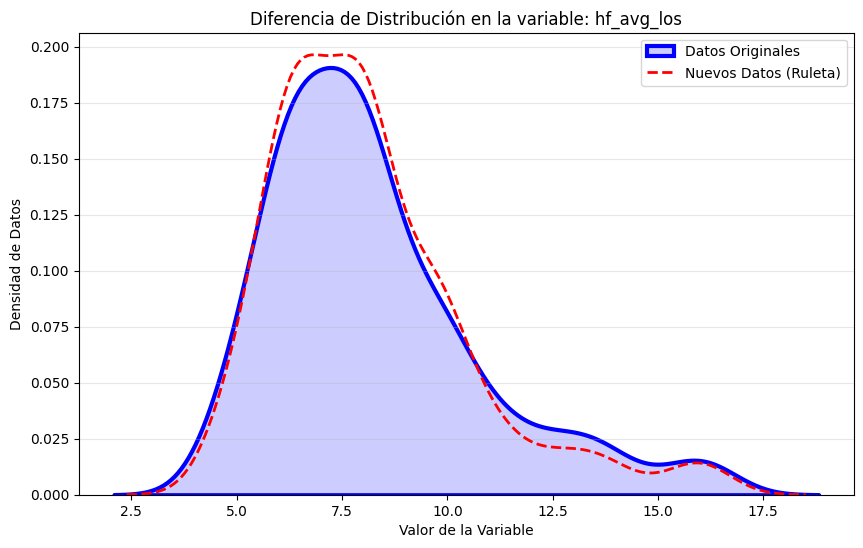

In [9]:
ubicacion_archivo = "../Ejercicio_3/Data/healthcare_outcomes_data.csv"
df_original = load_data_local(ubicacion_archivo)
if not df_original.empty:
    df_aumentado,solo_nuevos = aumentar_ruleta_con_validacion(df_original,150,config_sesgos)
    solo_nuevos.to_csv("../Ejercicio_3/Data/Phase_2/datos_nuevos_IGZ.csv", index=False)
    for columna in df_original.columns:
        if pd.api.types.is_numeric_dtype(df_original[columna]):
            graficar_diferencia_datos(df_original, df_aumentado, columna)

Fase Dos. Union de Datos sinteticos del Equipo 2 (Isaias y Erandeni)


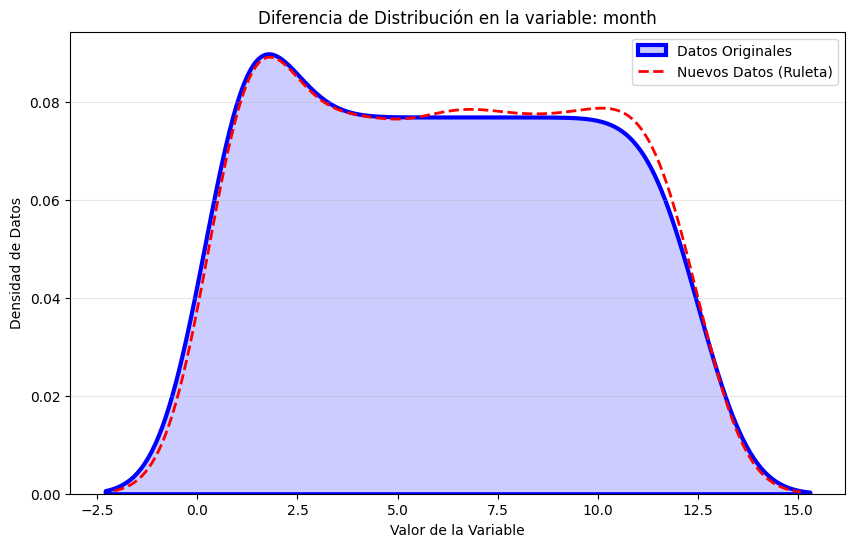

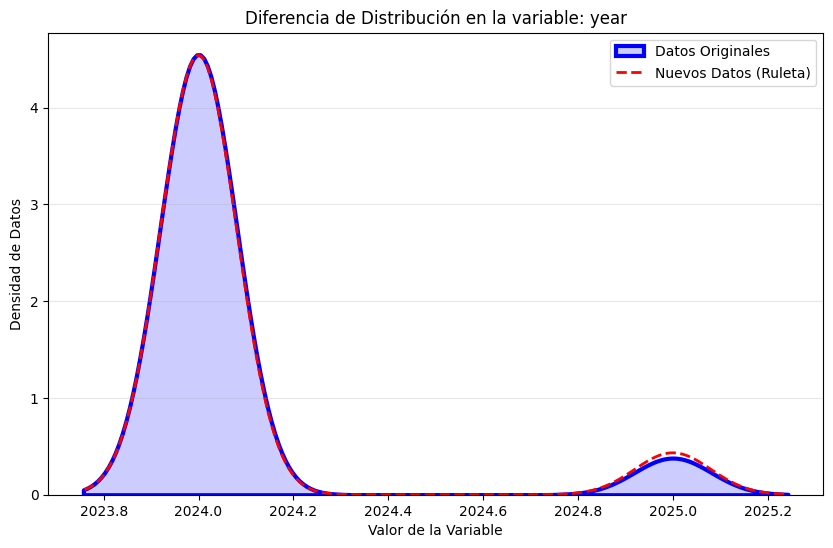

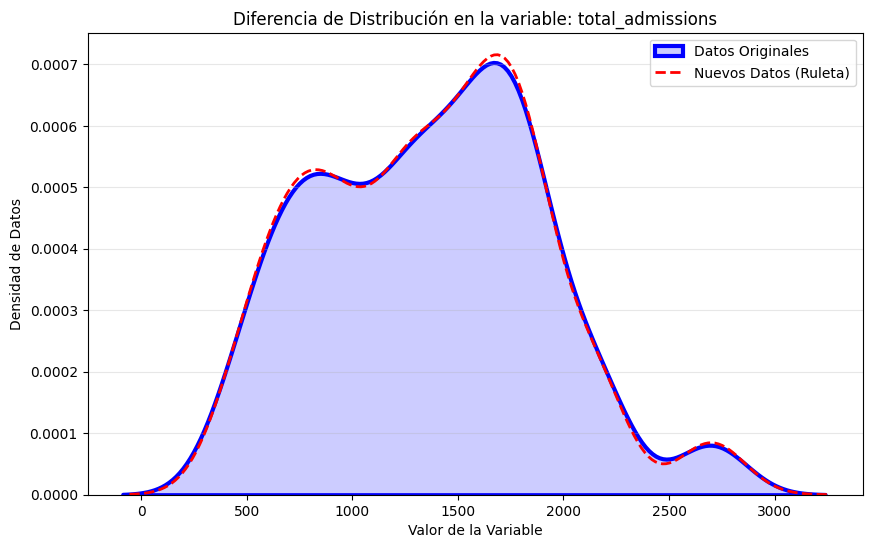

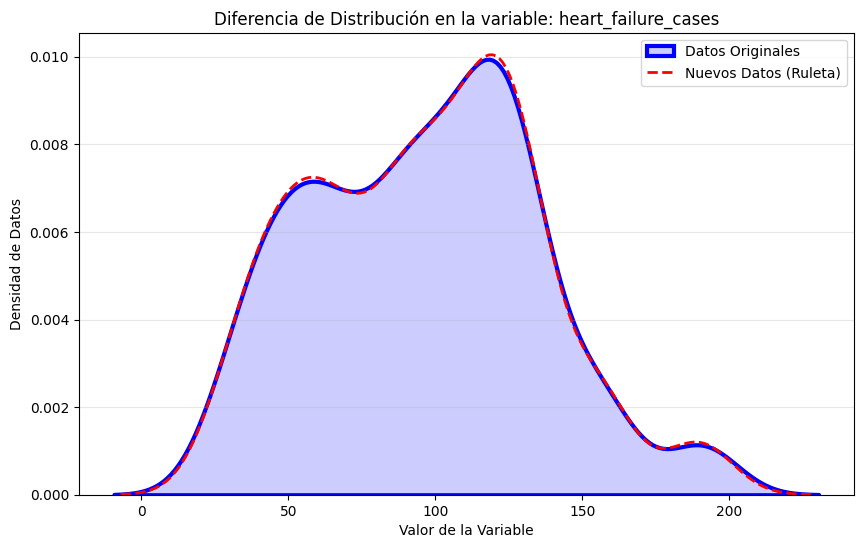

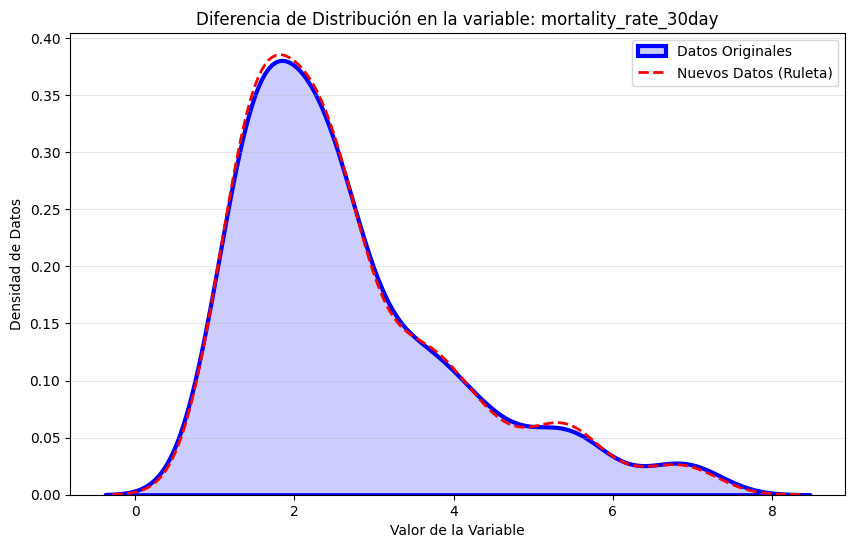

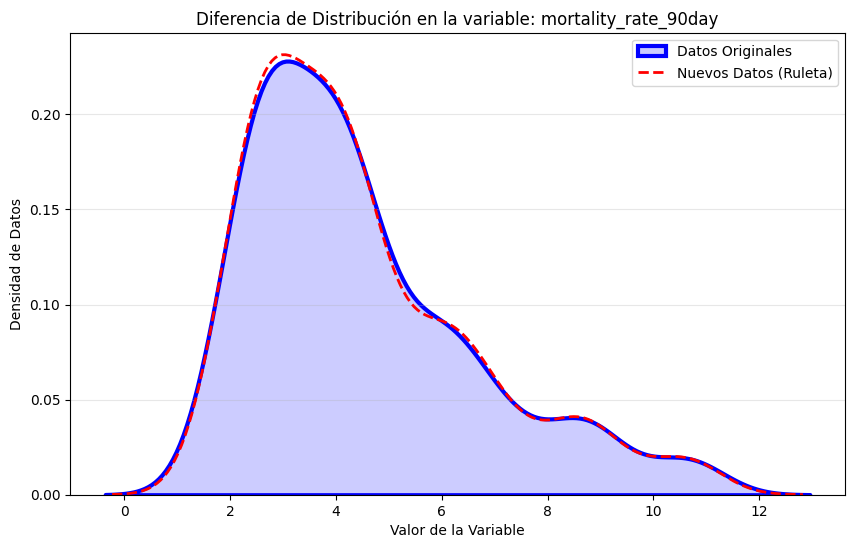

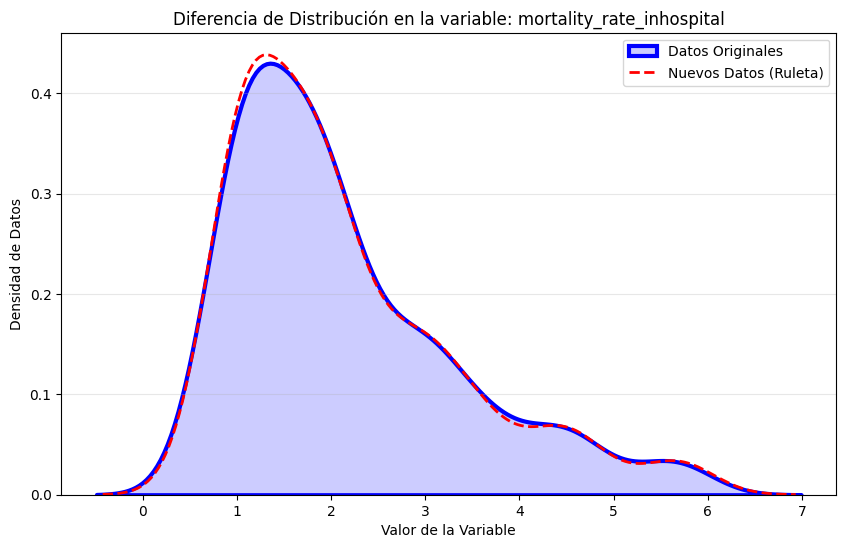

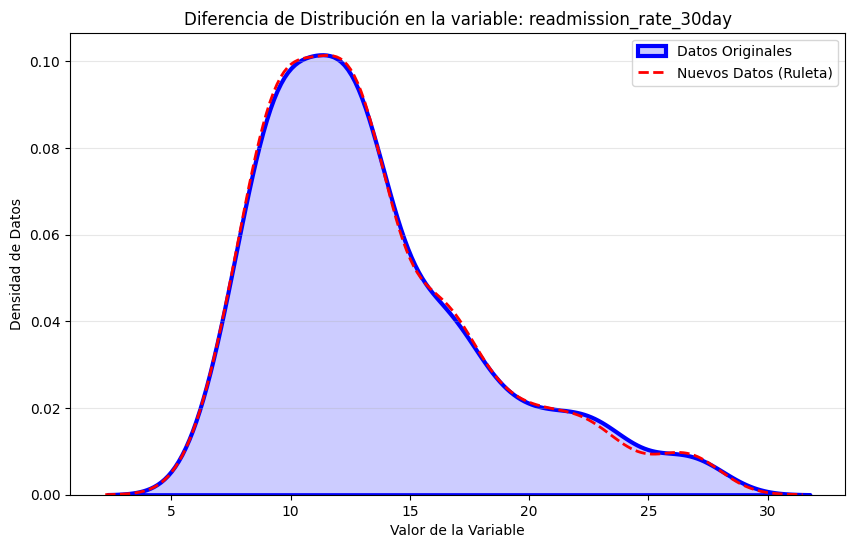

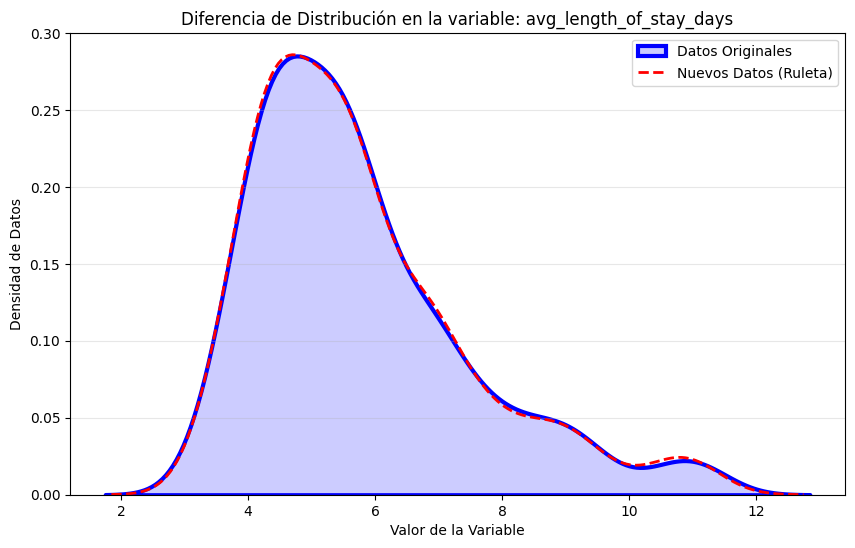

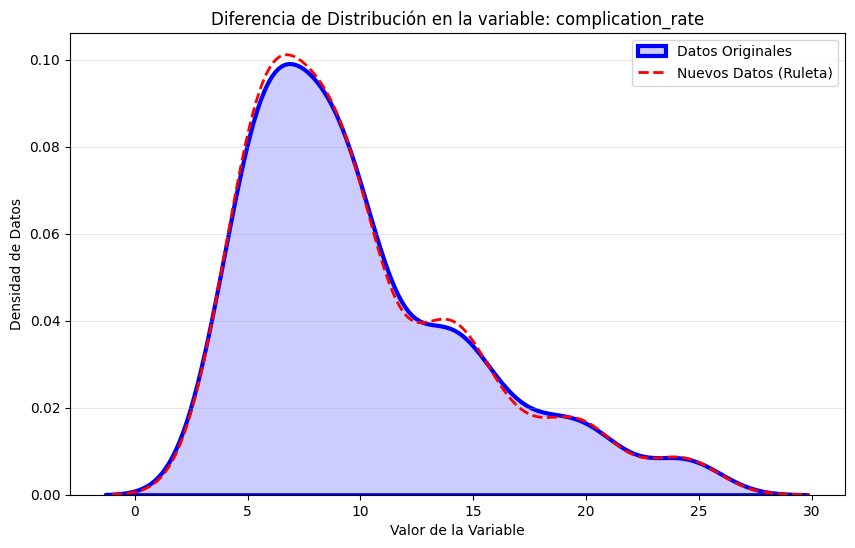

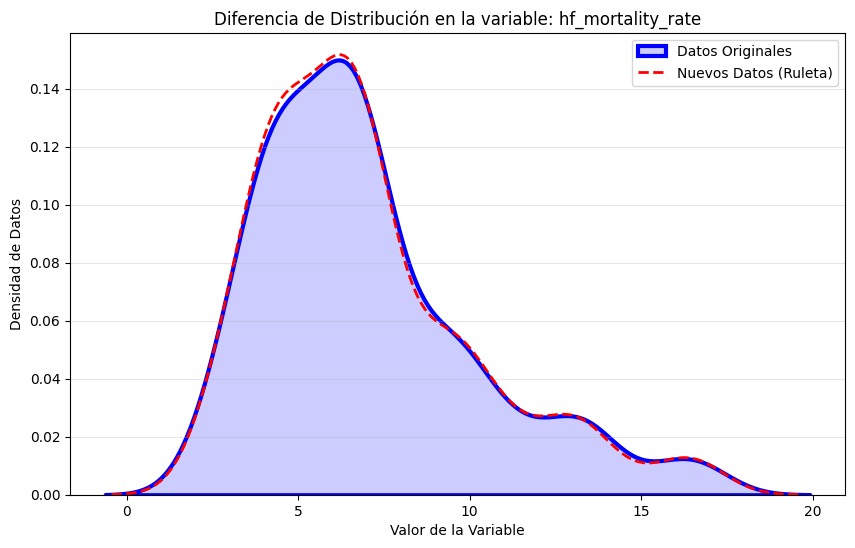

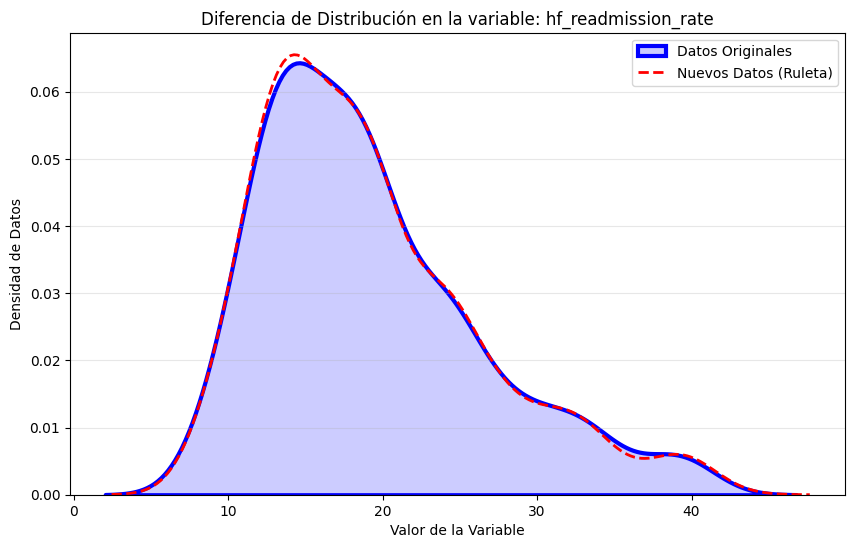

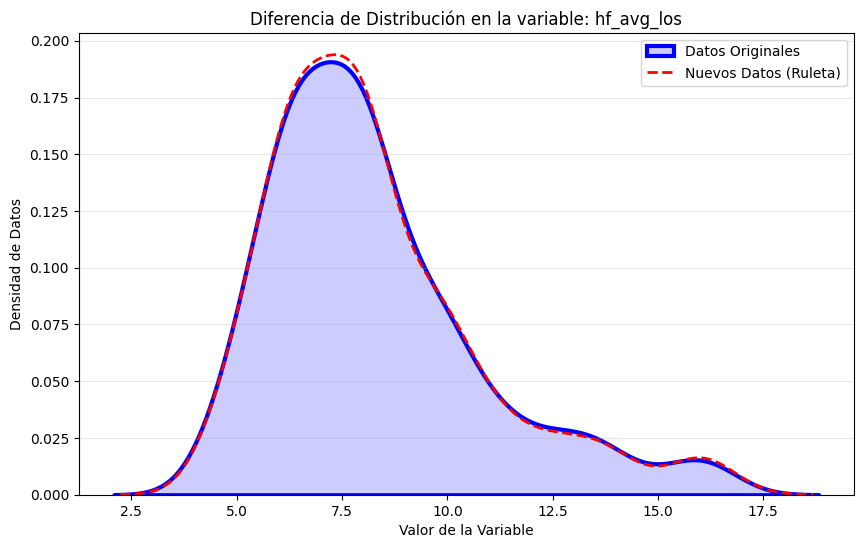

In [10]:
# Juntaremos primero los Datos de Erandeni y si no se ve una distribucion muy diferente juntaremos los mios. #
df_Erandeni = load_data_local("../Ejercicio_3/Data/Phase_2/healthcare_sinteticos_150_Erandeni.csv")
df_aumentado_primer = pd.concat([df_original,df_Erandeni],ignore_index=True)

if not df_aumentado_primer.empty:
    for columna in df_aumentado_primer.columns:
        if pd.api.types.is_numeric_dtype(df_aumentado_primer[columna]):
            graficar_diferencia_datos(df_original, df_aumentado_primer, columna)


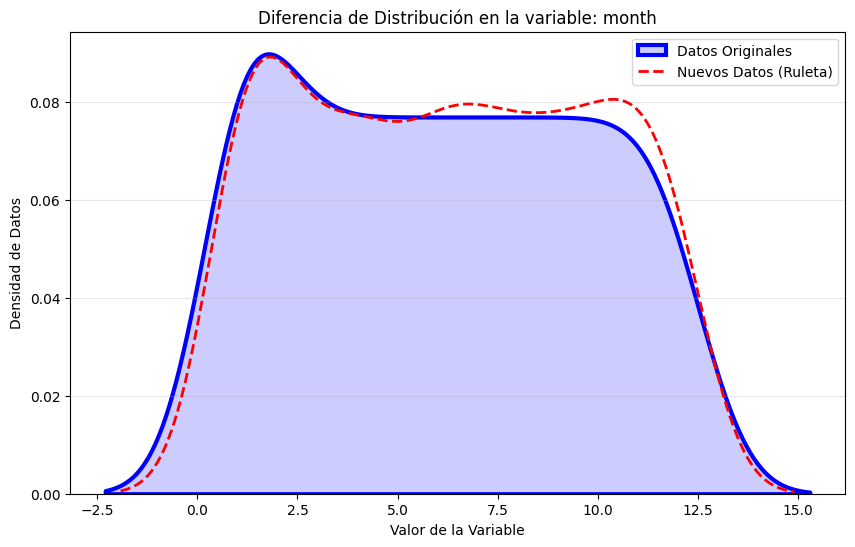

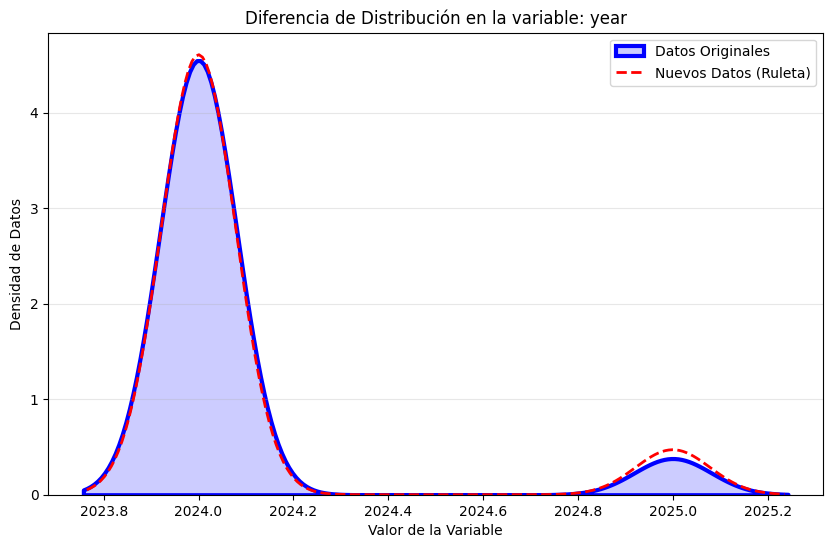

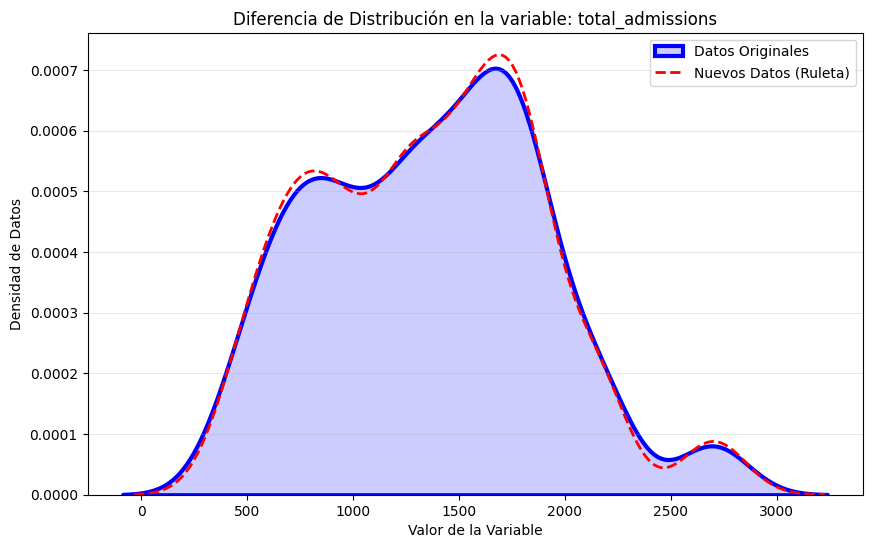

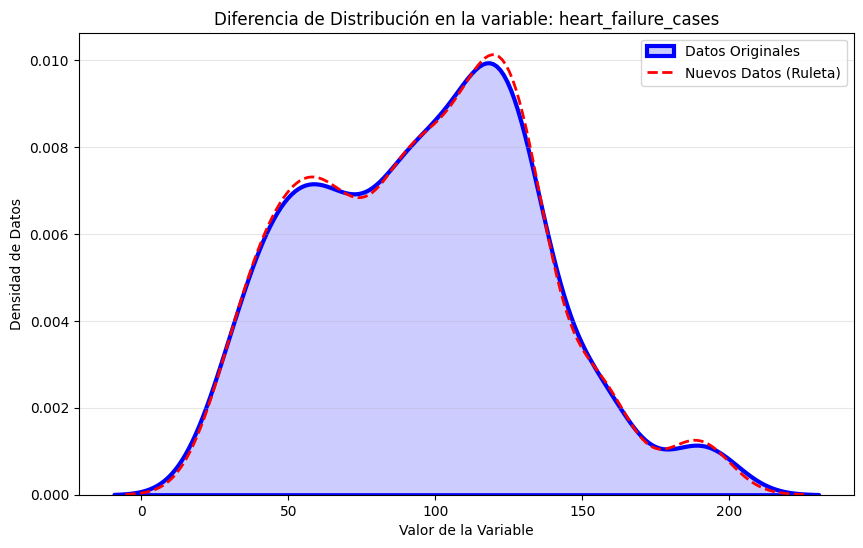

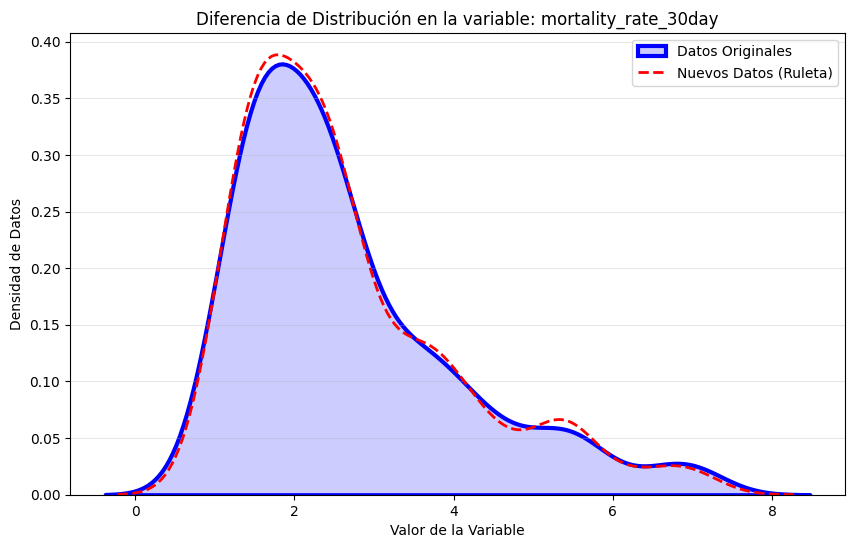

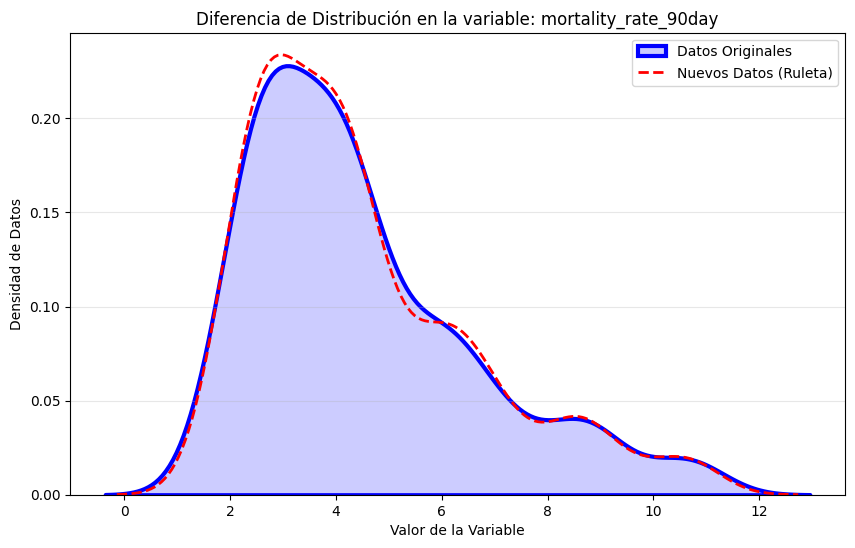

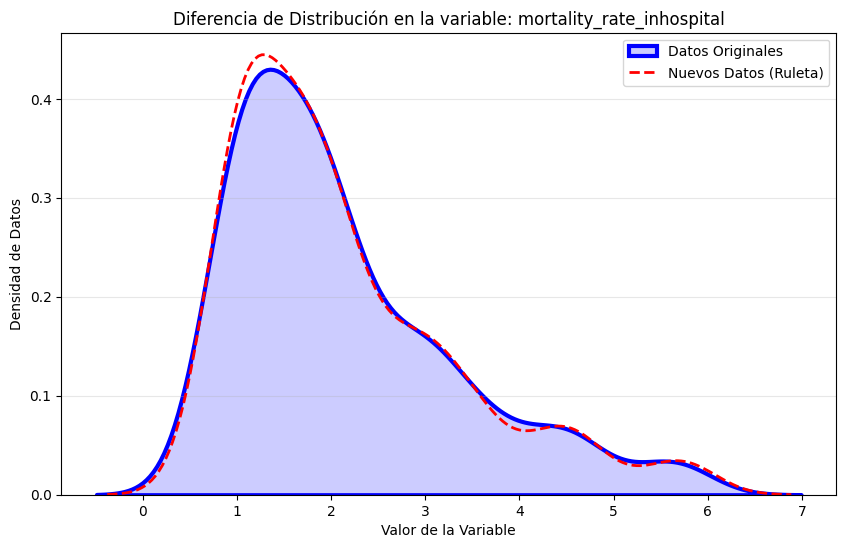

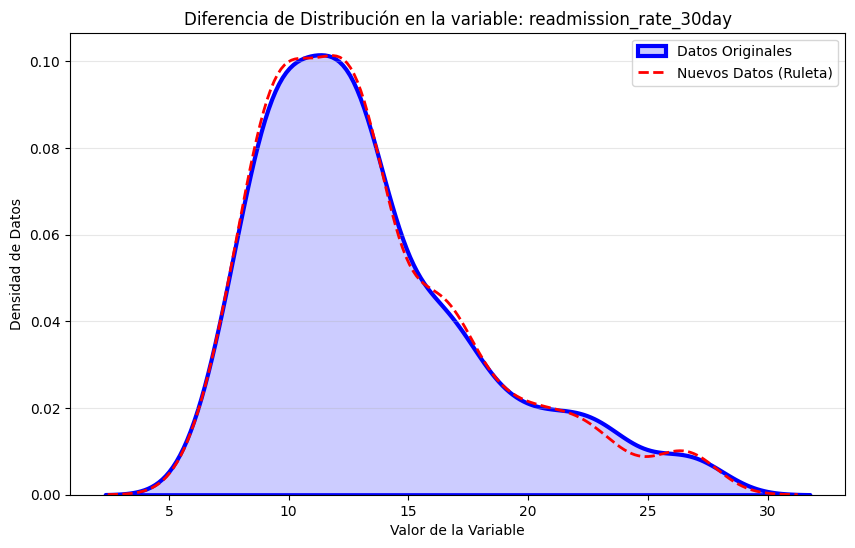

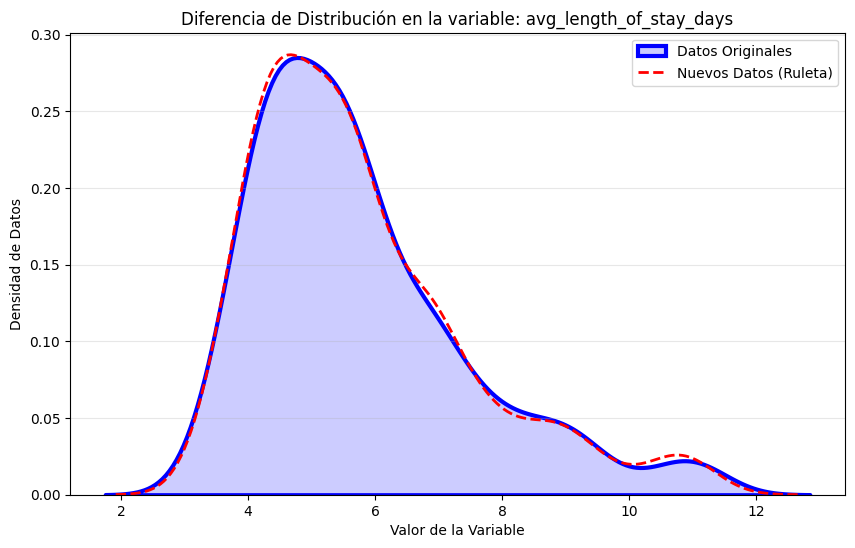

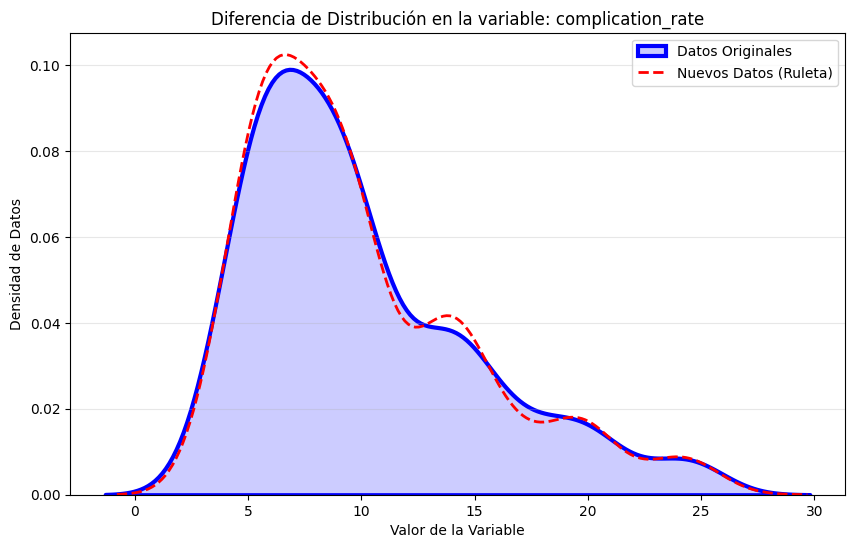

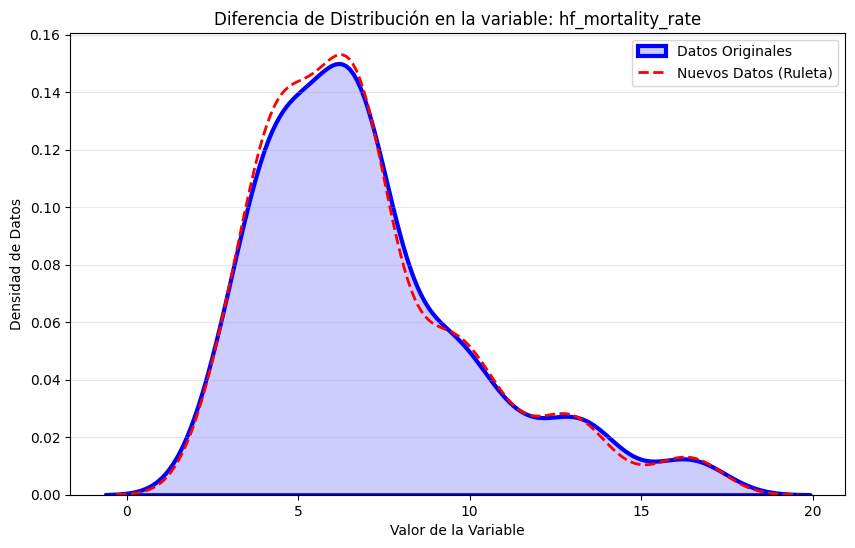

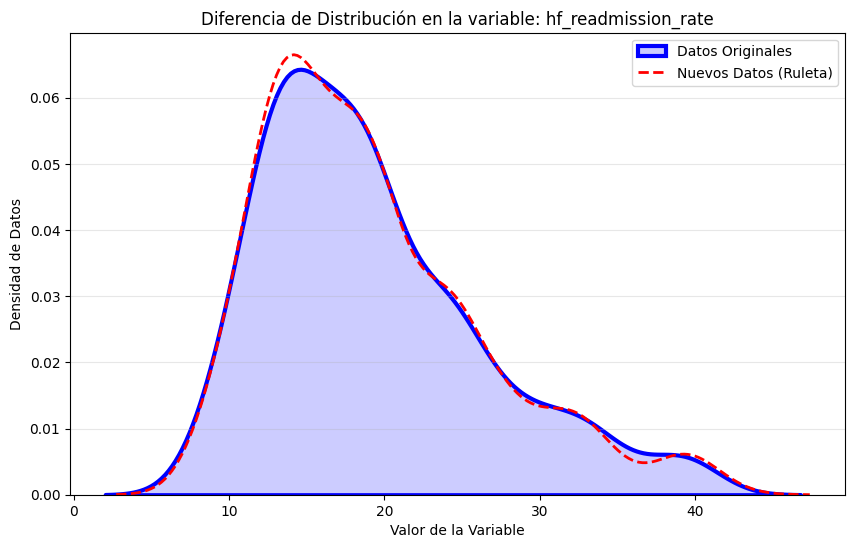

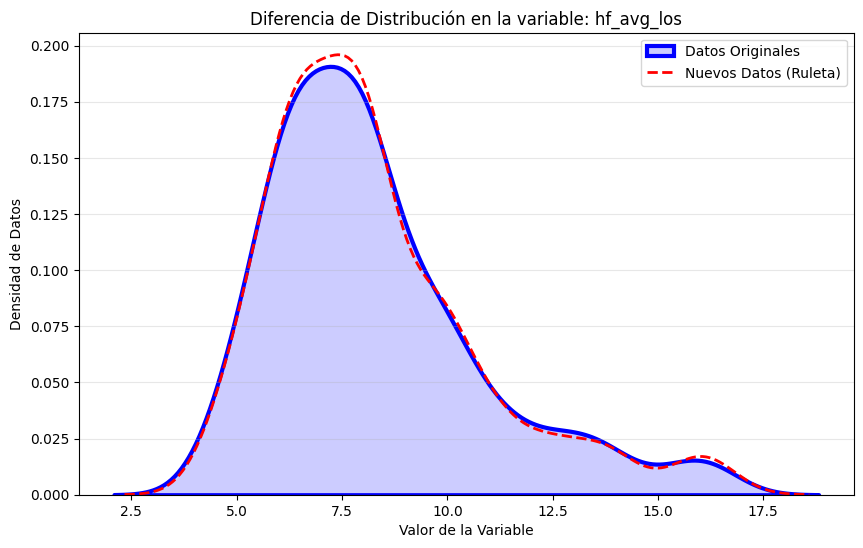

In [11]:
df_Isaias = load_data_local("../Ejercicio_3/Data/Phase_2/datos_nuevos_IGZ.csv")
df_aumentado_segundo= pd.concat([df_aumentado_primer,df_Erandeni],ignore_index=True)

if not df_aumentado_segundo.empty:
    for columna in df_aumentado_segundo.columns:
        if pd.api.types.is_numeric_dtype(df_aumentado_segundo[columna]):
            graficar_diferencia_datos(df_original, df_aumentado_segundo, columna)

# Guardamos la Data del equipo en un nuevo archivo#
df_equipo2 =pd.concat([df_Erandeni,df_Isaias],ignore_index=True)
df_equipo2 = df_equipo2.sort_values(by=['hospital_id'], ascending=[True])
df_equipo2.to_csv("../Ejercicio_3/Data/Phase_3/datos_sinteticos_Equipo2.csv", index=False)


Fase 3. Equipo 1 Vs Equipo 2

En esta fase lo que se hara es unir los datos de ambos equipos y observar si al momento de unir estos datos sigue siendo la misma distibucion en base a la original o ya son datos completamentes diferentes.

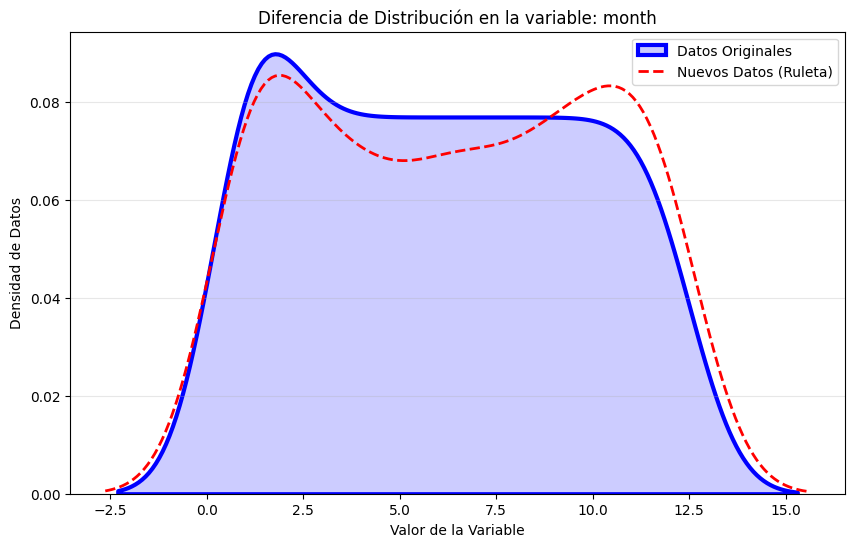

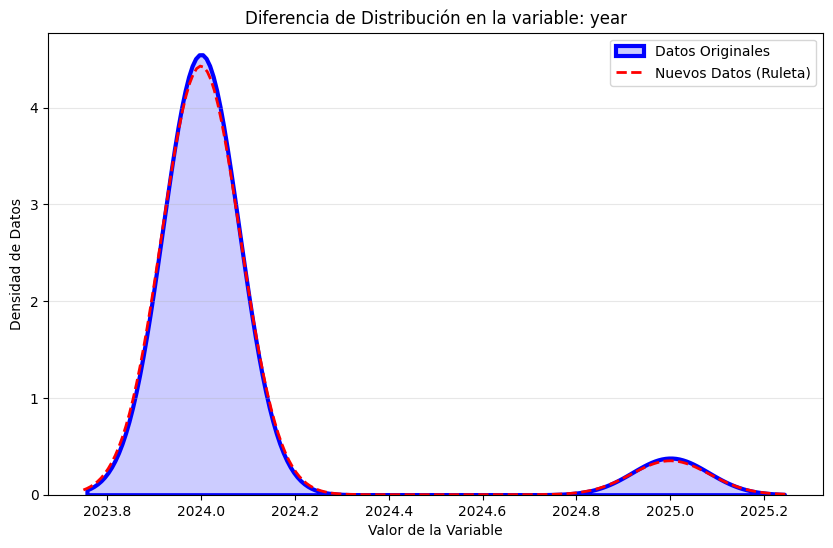

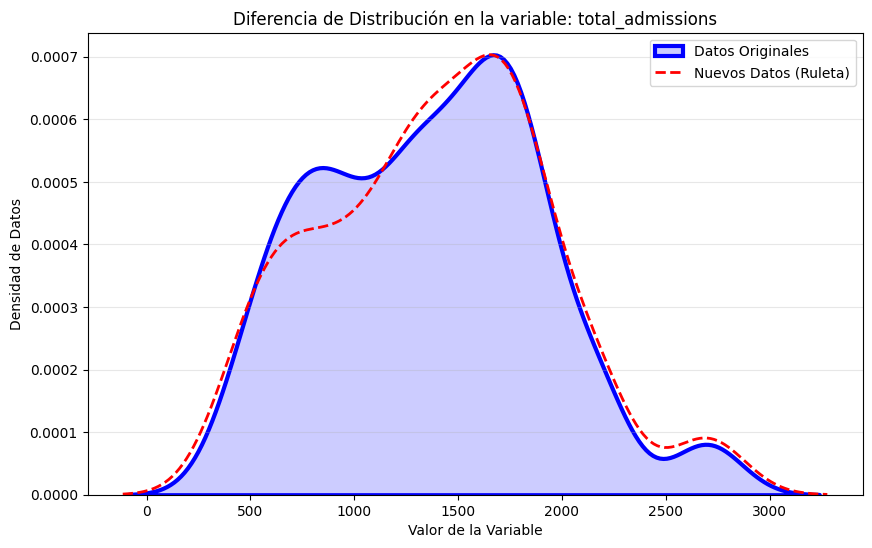

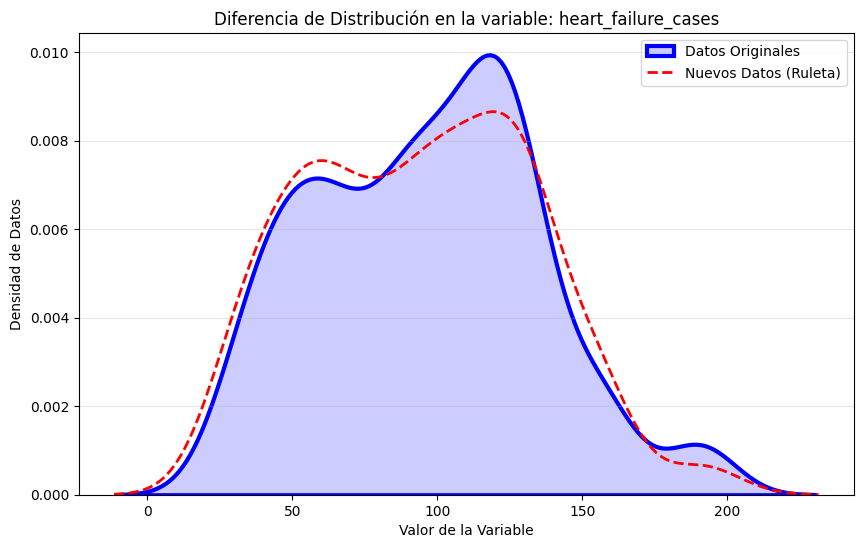

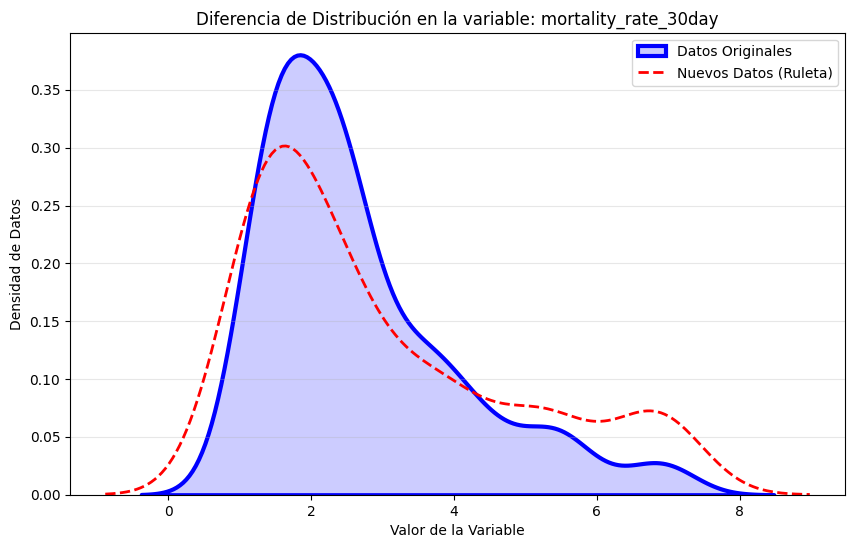

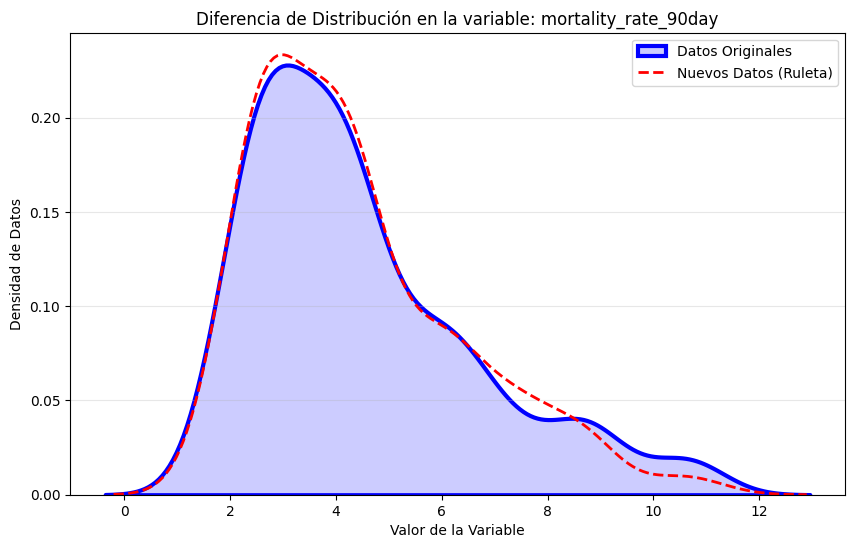

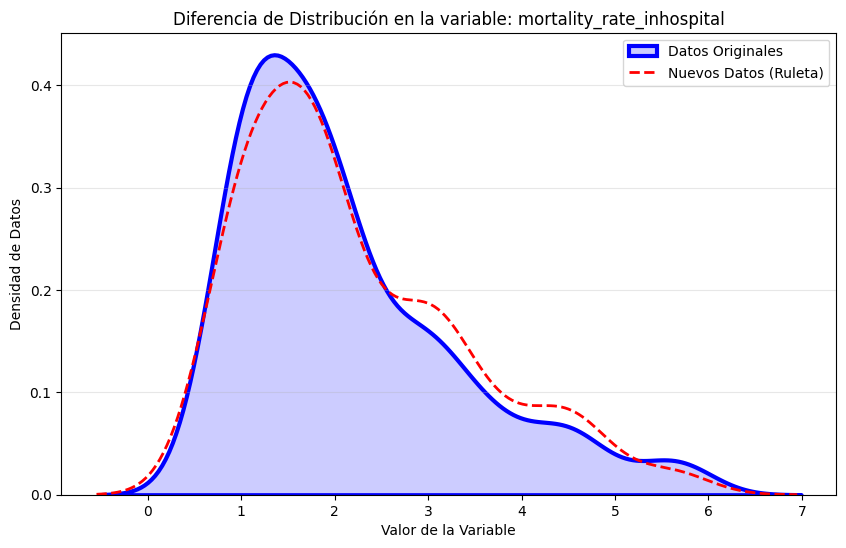

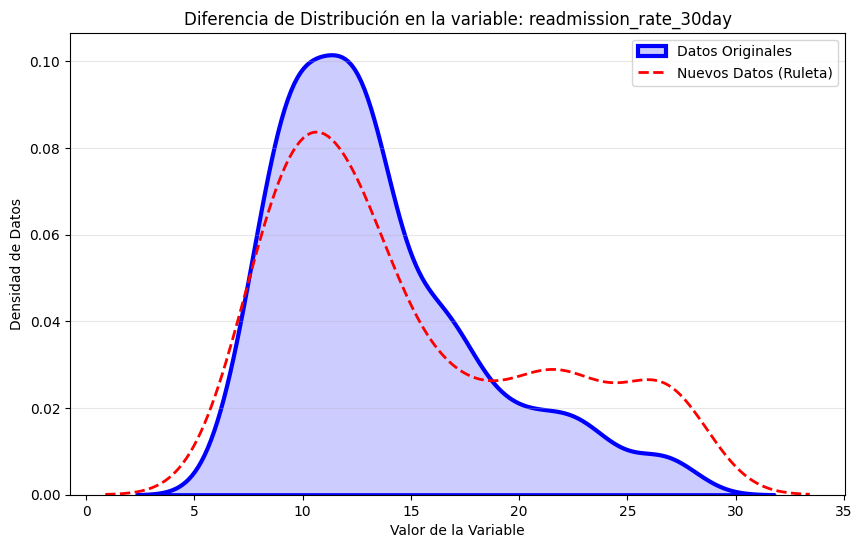

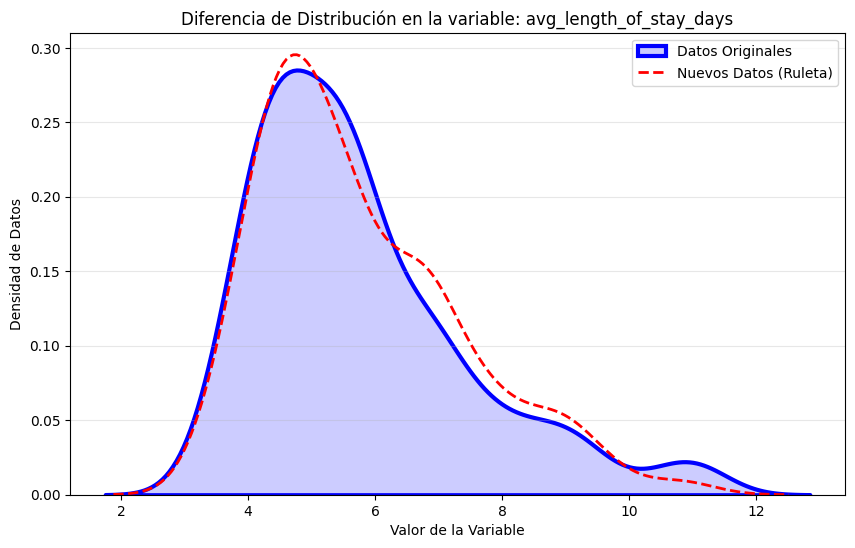

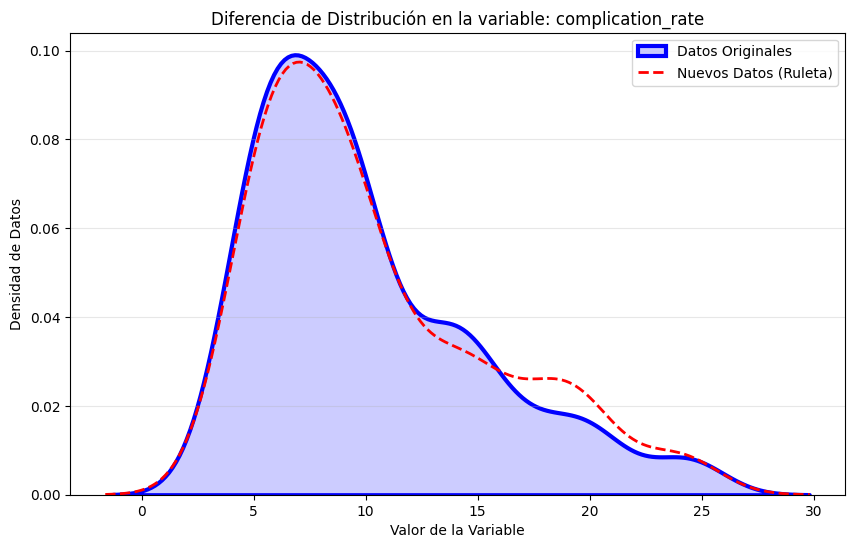

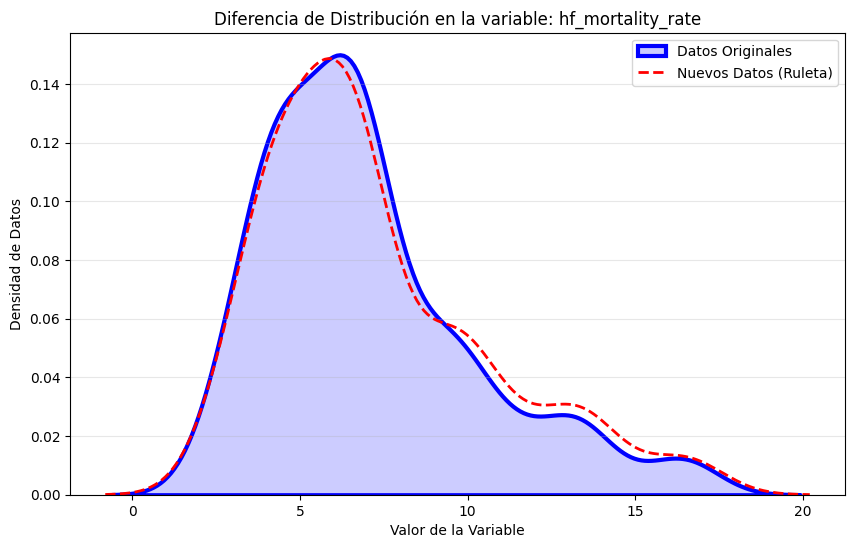

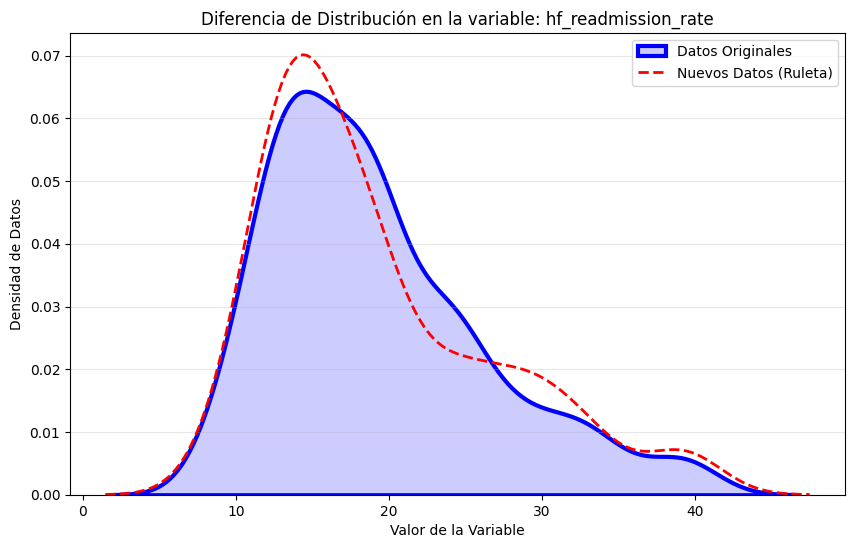

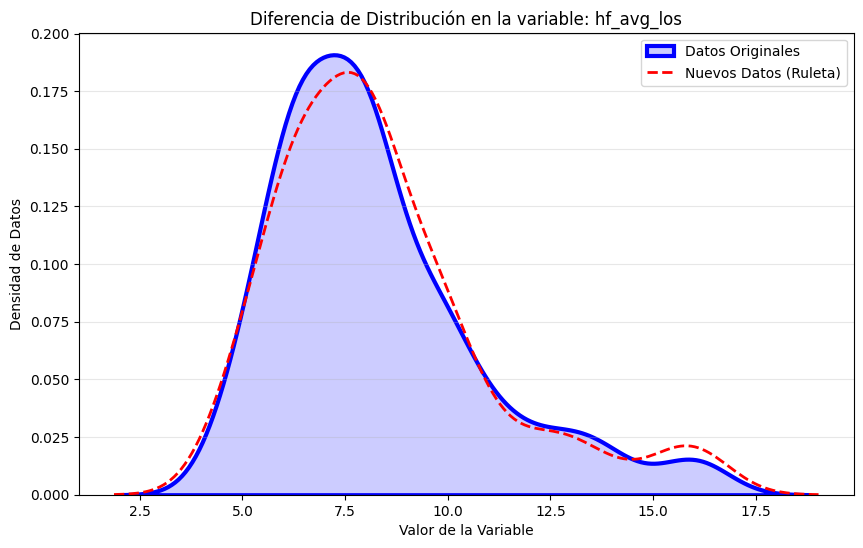

In [12]:
df_equipo1 = load_data_local("../Ejercicio_3/Data/Phase_3/hod_Synthetic_Equipo1.csv")
df_equipo2 = load_data_local("../Ejercicio_3/Data/Phase_3/datos_sinteticos_Equipo2.csv")
df_equipo1 = df_equipo1.sort_values(by=['hospital_id'], ascending=[True])

if not df_original.empty:
    for columna in df_original.columns:
        if pd.api.types.is_numeric_dtype(df_original[columna]):
            graficar_diferencia_datos(df_original, df_equipo1, columna)


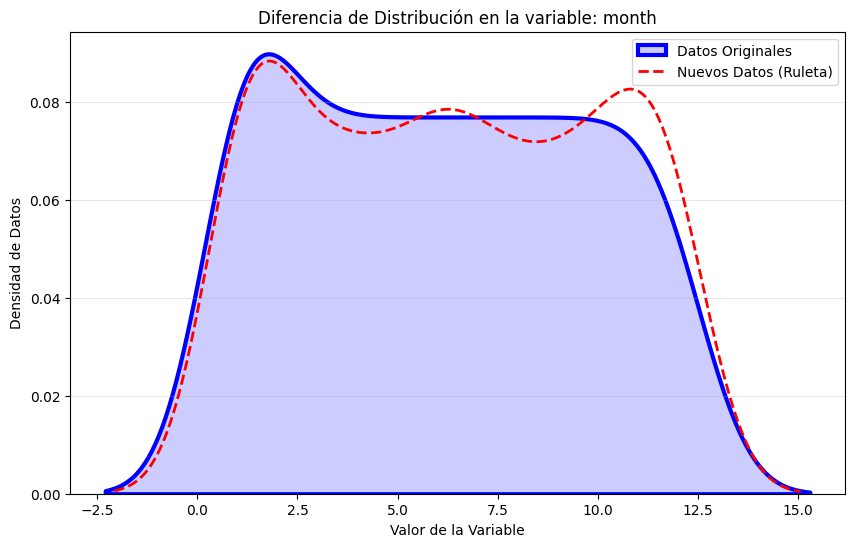

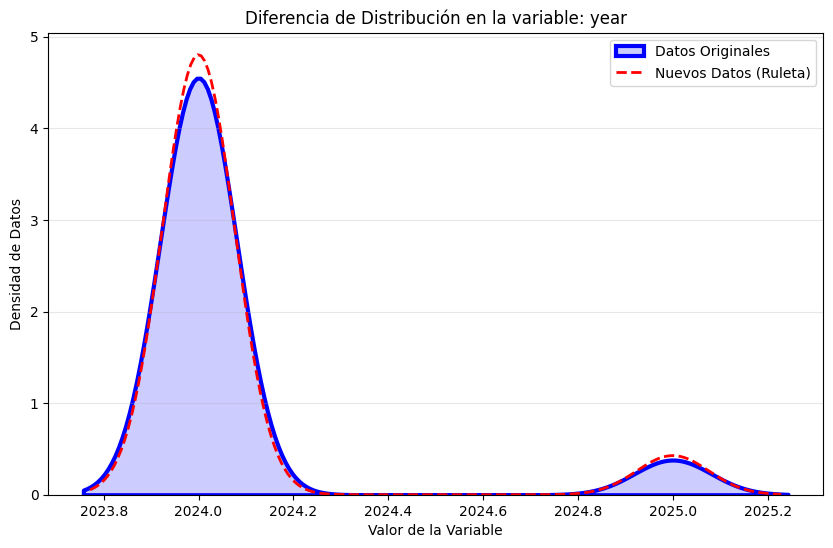

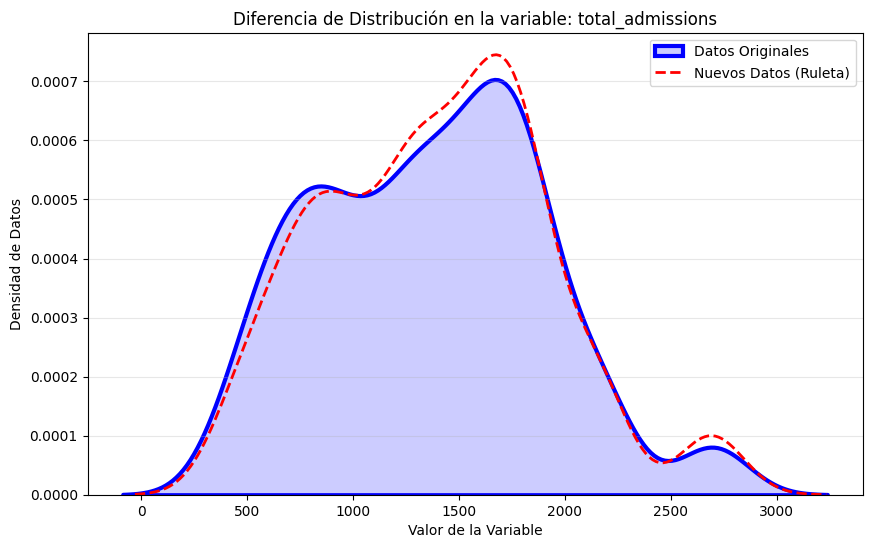

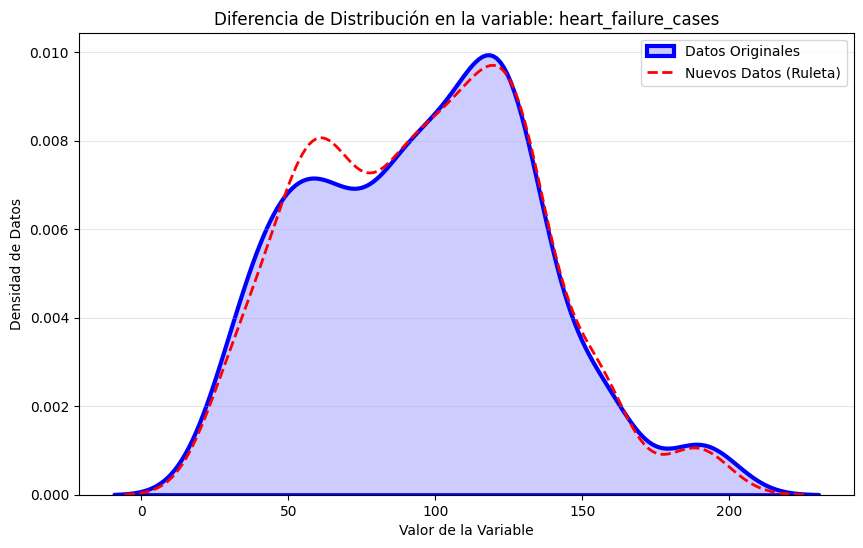

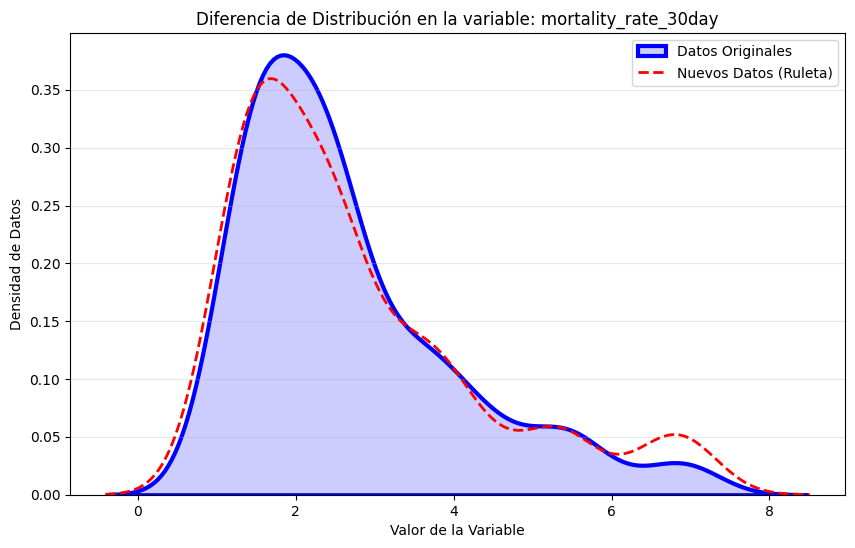

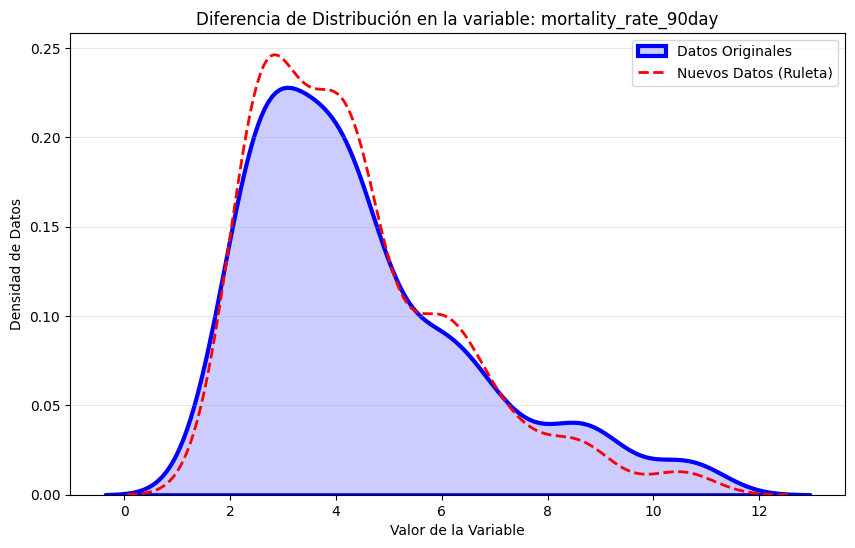

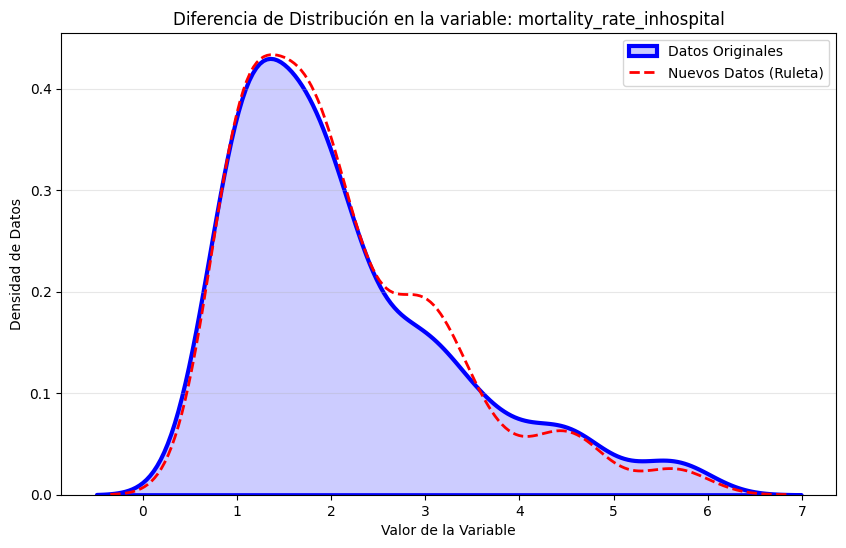

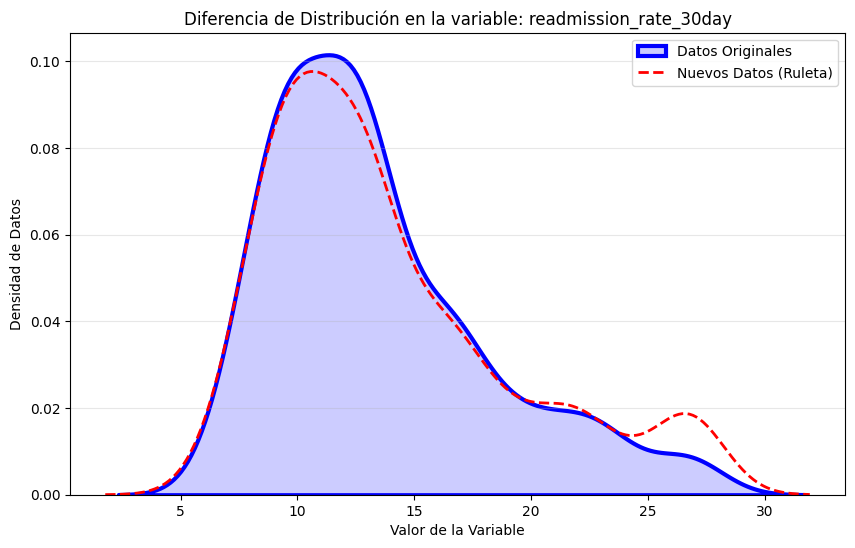

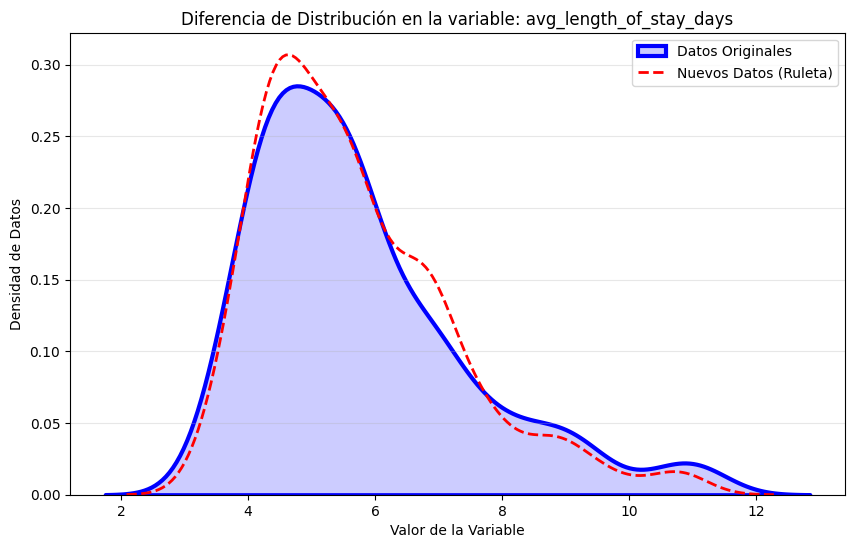

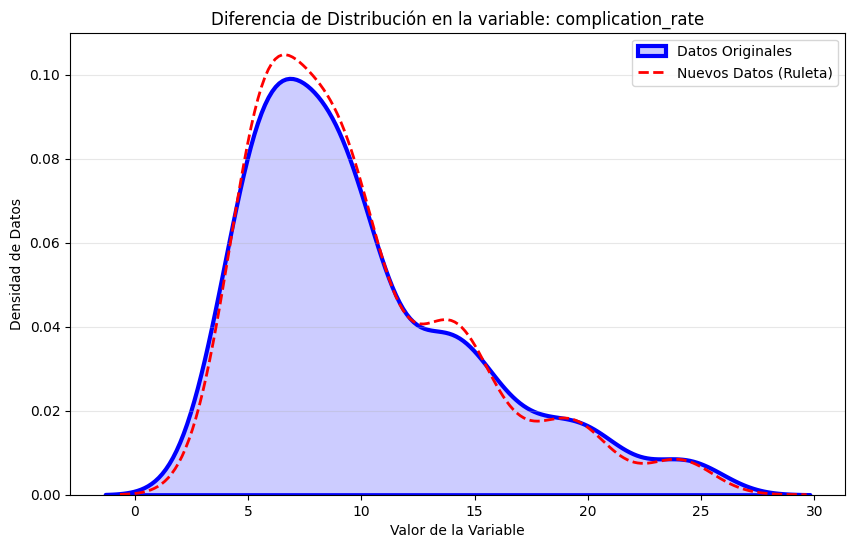

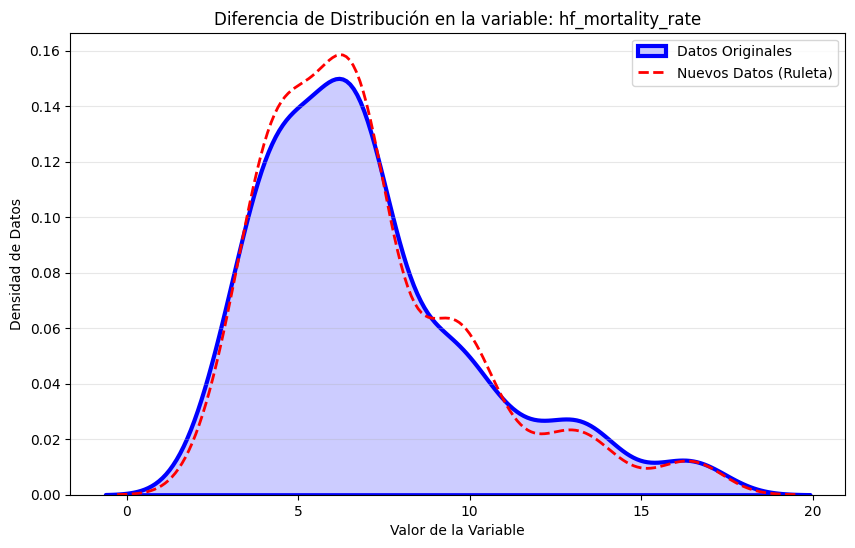

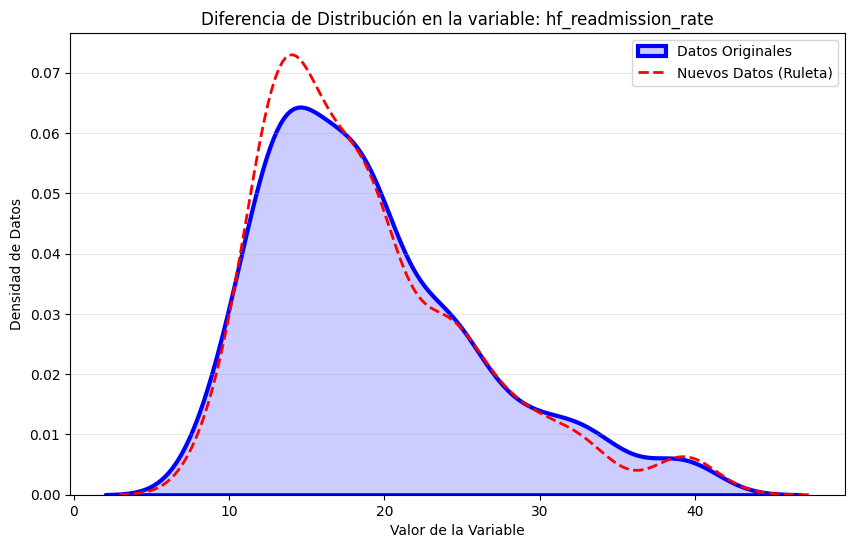

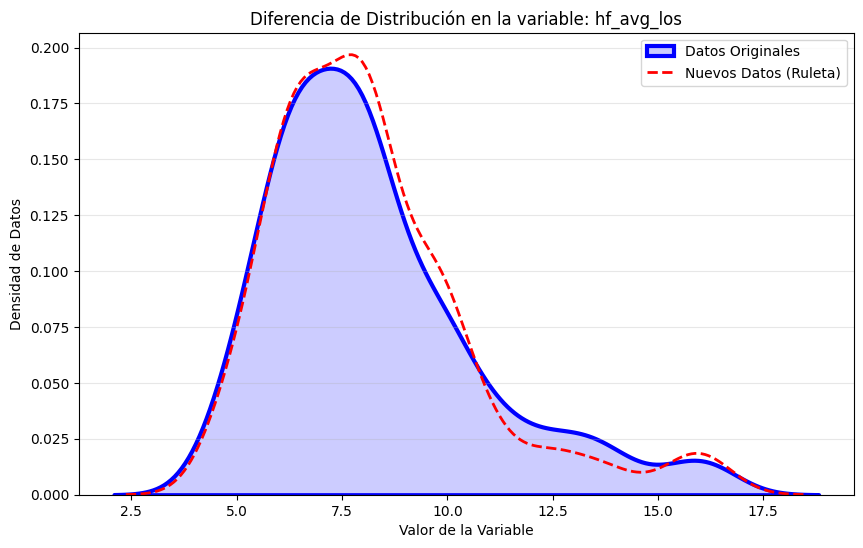

In [13]:
df_union = pd.concat([df_equipo1,df_equipo2],ignore_index=True)
if not df_original.empty:
    for columna in df_original.columns:
        if pd.api.types.is_numeric_dtype(df_original[columna]):
            # print(f"Original - Media: {df_original[columna].mean()}, Desv: {df_original[columna].std()}")
            # print(f"Aumentado - Media: {df_equipo2[columna].mean()}, Desv: {df_equipo2[columna].std()}")
            graficar_diferencia_datos(df_original, df_union, columna)
df_union = df_union.sort_values(by=['hospital_id'], ascending=[True])
df_union.to_csv("../Ejercicio_3/Data/healthcare_data_team_1&2.csv",index=False)